# KNN Project Implementation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

df = pd.read_csv('KNN_Project_Data')

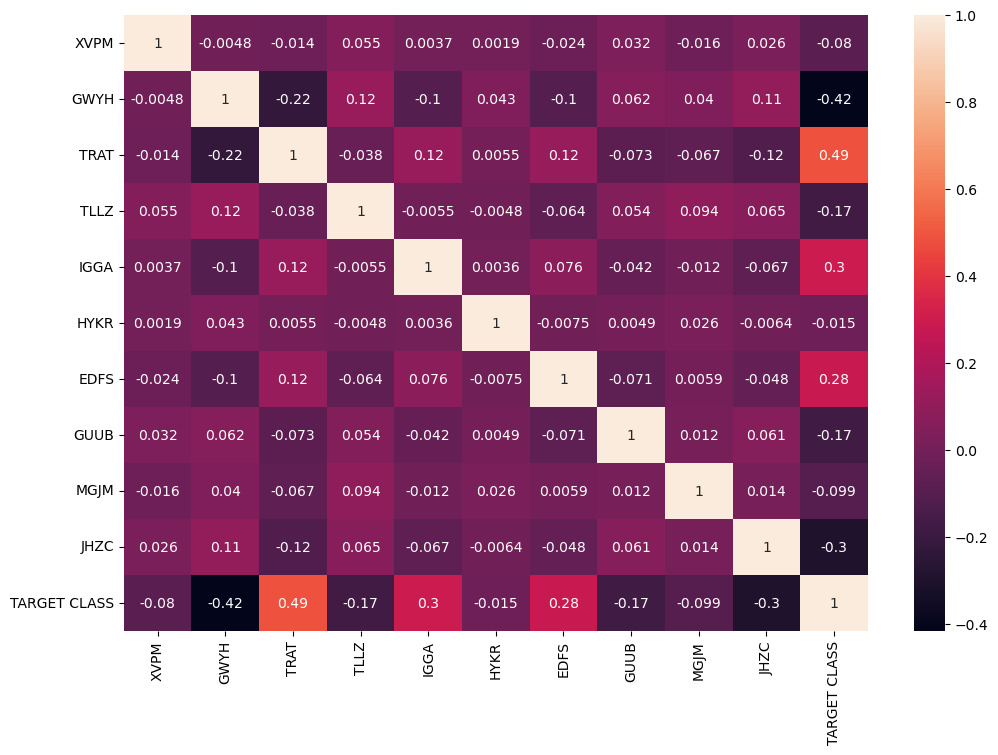

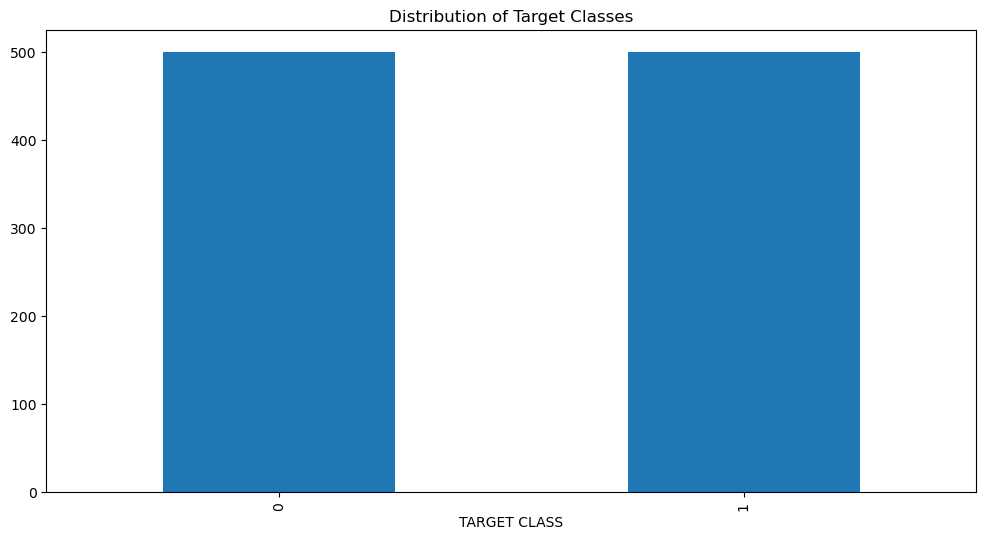

In [2]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True)
plt.show()

plt.figure(figsize=(12,6))
df['TARGET CLASS'].value_counts().plot(kind='bar')
plt.title('Distribution of Target Classes')
plt.show()

In [3]:
X = df.drop('TARGET CLASS', axis=1)
y = df['TARGET CLASS']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=101)

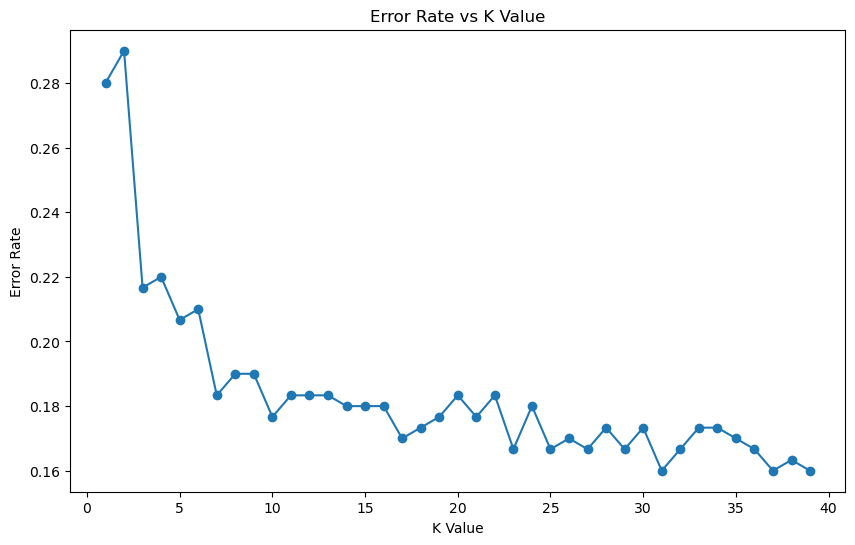

Optimal K value: 31


KNeighborsClassifier(n_neighbors=31)

In [4]:
error_rates = []

for i in range(1, 40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    error_rates.append(np.mean(pred != y_test))

plt.figure(figsize=(10,6))
plt.plot(range(1,40), error_rates, marker='o')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.title('Error Rate vs K Value')
plt.show()

optimal_k = error_rates.index(min(error_rates)) + 1
print(f"Optimal K value: {optimal_k}")

final_knn = KNeighborsClassifier(n_neighbors=optimal_k)
final_knn.fit(X_train, y_train)

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.81      0.84       152
           1       0.82      0.87      0.84       148

    accuracy                           0.84       300
   macro avg       0.84      0.84      0.84       300
weighted avg       0.84      0.84      0.84       300



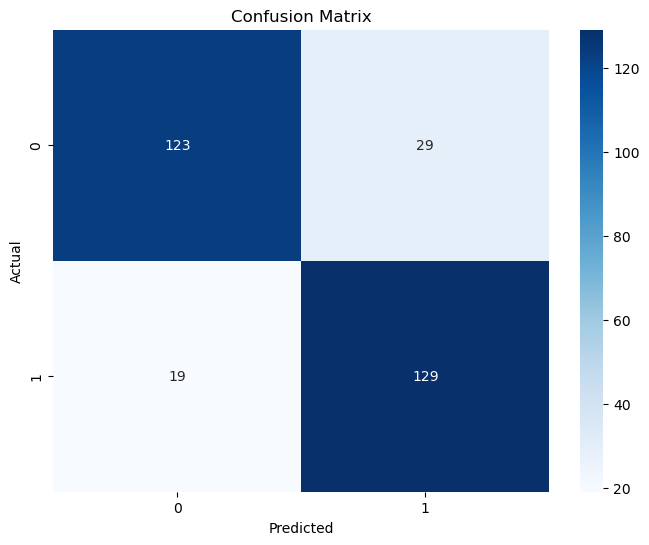

In [5]:
predictions = final_knn.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, predictions))

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [6]:
sample_point = X_test[0].reshape(1,-1)
prediction = final_knn.predict(sample_point)
probabilities = final_knn.predict_proba(sample_point)

print(f"Prediction for sample point: {prediction[0]}")
print(f"Probability of class 0: {probabilities[0][0]:.2f}")
print(f"Probability of class 1: {probabilities[0][1]:.2f}")
print(f"Actual value: {y_test.iloc[0]}")

Prediction for sample point: 1
Probability of class 0: 0.00
Probability of class 1: 1.00
Actual value: 1
